In [3]:
import os
import sys
from sys import path
sys.path.append(os.path.expanduser('~/albatros_analysis'))
import numpy as np 
import numba as nb
import time
from scipy import linalg
from scipy import stats
from matplotlib import pyplot as plt
from datetime import datetime as dt
from src.correlations import baseband_data_classes as bdc
from src.utils import baseband_utils as butils
from src.utils import orbcomm_utils as outils
from scipy.optimize import least_squares
import json
#import extra_functions as ef
import random
#import h5py
from scripts.xcorr import helper as hp
import importlib
from scipy.interpolate import interp1d

BDC is using numpy


In [62]:
#CHECK TO SEE IF THIS MAKES SENSE/IS ALLOWED
def interp_rect(vis):

    #interpolates rectangular form
    t = np.arange(len(vis))
    valid = ~vis.mask

    real_interp = interp1d(t[valid], vis[valid].real, kind='linear', fill_value="extrapolate")
    imag_interp = interp1d(t[valid], vis[valid].imag, kind='linear', fill_value="extrapolate")
    
    vis_interp = real_interp(t) + 1j * imag_interp(t) 
    return vis_interp  

In [63]:
config_path = '/home/thomasb/albatros_analysis/scripts/orbcomm'
config_name = 'config.json'

satdet_path = '/scratch/thomasb'
satdet_name = "pulsedata_1753133403_1757357733.0631413.json"

antennas = {}

In [64]:
with open(f"{config_path}/{config_name}", "r") as f:
    config = json.load(f)
    for i, (ant, details) in enumerate(config["antennas"].items()):
        antennas[details["name"]] = {}
        antennas[details["name"]]['coordinates'] = details['coordinates']
        antennas[details["name"]]['path'] = details['path']
        if i ==0:
            antennas[details["name"]]['reference'] = 'T'
        else:
            antennas[details["name"]]['reference'] = 'F'

    global_start_time = config["correlation"]["start_timestamp"]
    global_end_time = config["correlation"]["end_timestamp"]
    v_acclen = config["correlation"]["vis_acclen"]
    T_SPECTRA = 4096/250e6
print(antennas)
print("Visibility Accumulation Length", v_acclen)
print(global_start_time)
print(global_end_time)
print(T_SPECTRA)

V_T_ACCLEN = v_acclen* T_SPECTRA
tle_path = outils.get_tle_file(global_start_time, "/project/rrg-sievers/mohanagr/OCOMM_TLES")

{'Antenna 1': {'coordinates': [79.41718333333333, -90.76735, 189], 'path': '/scratch/mohanagr/summer_2025/baseband/mars1', 'reference': 'T'}, 'Antenna 2': {'coordinates': [79.41721666666666, -90.75885, 176], 'path': '/scratch/mohanagr/summer_2025/baseband/mars2', 'reference': 'F'}, 'Antenna 4': {'coordinates': [79.38846667, -91.01926667, 22], 'path': '/scratch/mohanagr/summer_2025/baseband/mars4', 'reference': 'F'}, 'Antenna 6': {'coordinates': [79.398, -90.79993333, 43], 'path': '/scratch/mohanagr/summer_2025/baseband/mars6', 'reference': 'F'}, 'Antenna 7': {'coordinates': [79.41148333, -90.69531667, 26], 'path': '/scratch/mohanagr/summer_2025/baseband/mars7', 'reference': 'F'}, 'Antenna 8': {'coordinates': [79.44376667, -90.7325, 406], 'path': '/scratch/mohanagr/summer_2025/baseband/mars8', 'reference': 'F'}}
Visibility Accumulation Length 30000
1753133403
1753140603
1.6384e-05


In [65]:
with open(f'{satdet_path}/{satdet_name}') as f:
    pulsedata = json.load(f)
    ants = pulsedata[f'{global_start_time}']
    print(ants)
    for ant, details in ants.items():
        antennas[ant]['consensus_offset'] = details['consensus_offset']
        antennas[ant]['pulse_data'] = details['pulse_data']

{'Antenna 2': {'consensus_offset': 115507586, 'pulse_data': [{'start': 0, 'end': 61, 'sats_present': {'28654': [[1841, 'UNRELIABLE']], '25338': [[1841, 'UNRELIABLE']]}, 'individual_offset': 115507586, 'diff_to_consensus': 0}, {'start': 0, 'end': 61, 'sats_present': {'28654': [[1841, 'UNRELIABLE']], '25338': [[1841, 'UNRELIABLE']]}, 'individual_offset': 115507586, 'diff_to_consensus': 0}, {'start': 61, 'end': 97, 'sats_present': {'25338': [[1841, 'UNRELIABLE'], [1842, 'UNRELIABLE'], [1846, 'UNCLEAR']]}, 'individual_offset': 115507662, 'diff_to_consensus': -76}, {'start': 168, 'end': 281, 'sats_present': {'33591': [[1850, 'UNRELIABLE']]}, 'individual_offset': 115507586, 'diff_to_consensus': 0}, {'start': 680, 'end': 748, 'sats_present': {'59051': [[1836, 'RELIABLE'], [1837, 'RELIABLE']]}, 'individual_offset': 115507586, 'diff_to_consensus': 0}, {'start': 855, 'end': 917, 'sats_present': {'57166': [[1836, 'UNCLEAR'], [1837, 'RELIABLE']], '44387': [[1836, 'UNCLEAR'], [1837, 'RELIABLE']]}, 

In [66]:
current_name = 'Antenna 2'
current_dict = antennas[f'{current_name}']
consensus_offset = antennas[f'{current_name}']['consensus_offset']
observed_data = []

for pulse_idx, p in enumerate(antennas[f'{current_name}']['pulse_data']):
    
    if pulse_idx >1:
        continue
    
    print(f"---------STARTING PULSE {pulse_idx}---------")
    print(p)
    #--------times-----

    relative_start_time = p['start']
    relative_end_time = p['end']
    t_start = global_start_time + relative_start_time
    pulse_len_s = relative_end_time - relative_start_time
    print("rel. start, end t:", relative_start_time, relative_end_time)
    print("global start t:", t_start)

    max_window = 600
    if pulse_len_s > max_window:
        t_end = t_start + max_window
        print("pulse too long, vislen cut to:", max_window)
        t_end = t_start + max_window
    else:
        pulse_len_s += 20
        print("vislen:", pulse_len_s)
        t_end = t_start + pulse_len_s

    pulse_len_chunks = int(np.ceil((pulse_len_s)/(T_SPECTRA * v_acclen)))
    print("pulse chunk len:", pulse_len_chunks)

    #-------other data--------
    ra_path = antennas["Antenna 1"]['path']
    nra_path = antennas[f"{current_name}"]['path']
    individual_offset = p['individual_offset']

    #----get initialized information----
    files_a1, idx1 = butils.get_init_info(t_start, t_end, ra_path)
    files_a2, idx2 = butils.get_init_info(t_start, t_end, nra_path)

    #-------set up channels-------
    channels = bdc.get_header(files_a1[0])["channels"].astype('int64')
    chanstart = np.where(channels == 1834)[0][0] 
    chanend = np.where(channels == 1852)[0][0]
    nchans=chanend-chanstart
    
    
    #chan_bigidx = info[pulse_idx][2]
    #print("Large Channel idx", chan_bigidx)
    #chanmap = channels[chanstart:chanend].astype(int)
    #chan_smallidx = np.where(chanmap == chan_bigidx)[0][0]
    #print("Small Channel idx", chan_smallidx)

    #--------call get_avg_fast----------
    time_pulse=time.time()
    pols, rowcounts, channels = hp.get_avg_fast(ra_path, nra_path, t_start, t_end, consensus_offset, v_acclen, pulse_len_chunks, chanstart=chanstart, chanend=chanend)
    
    pulse_vis = np.empty((pulse_len_chunks, nchans), dtype=np.complex128)
    for i in range(nchans):
        pulse_vis[:, i] = interp_rect(pols[0][:, i])
    
    observed_data.append(pulse_vis)


    print(f"DONE PULSE {pulse_idx}. TIME:", time.time()-time_pulse) 

---------STARTING PULSE 0---------
{'start': 0, 'end': 61, 'sats_present': {'28654': [[1841, 'UNRELIABLE']], '25338': [[1841, 'UNRELIABLE']]}, 'individual_offset': 115507586, 'diff_to_consensus': 0}
rel. start, end t: 0 61
global start t: 1753133403
vislen: 81
pulse chunk len: 165


Not reading any data
took 0.112 seconds to read raw data on  /scratch/mohanagr/summer_2025/baseband/mars1/17531/1753133359.raw
took 0.100 seconds to read raw data on  /scratch/mohanagr/summer_2025/baseband/mars2/17531/1753133371.raw
before correction 2685547 1953125
after correction 2685547 1931529
Starting at:  2685547 in filenum:  /scratch/mohanagr/summer_2025/baseband/mars1/17531/1753133359.raw for antenna 1
Starting at:  1931529 in filenum:  /scratch/mohanagr/summer_2025/baseband/mars2/17531/1753133371.raw for antenna 2
ACCLEN RECEIVED IS 30000
took 0.110 seconds to read raw data on  /scratch/mohanagr/summer_2025/baseband/mars1/17531/1753133359.raw
START SPECNUM IS 1203744667 obj start at 1201059120
ACCLEN RECEIVED IS 30000
took 0.100 seconds to read raw data on  /scratch/mohanagr/summer_2025/baseband/mars2/17531/1753133371.raw
START SPECNUM IS 1088237081 obj start at 1086305552
1 CHUNK READ
took 0.097 seconds to read raw data on  /scratch/mohanagr/summer_2025/baseband/mars1/17531/

7


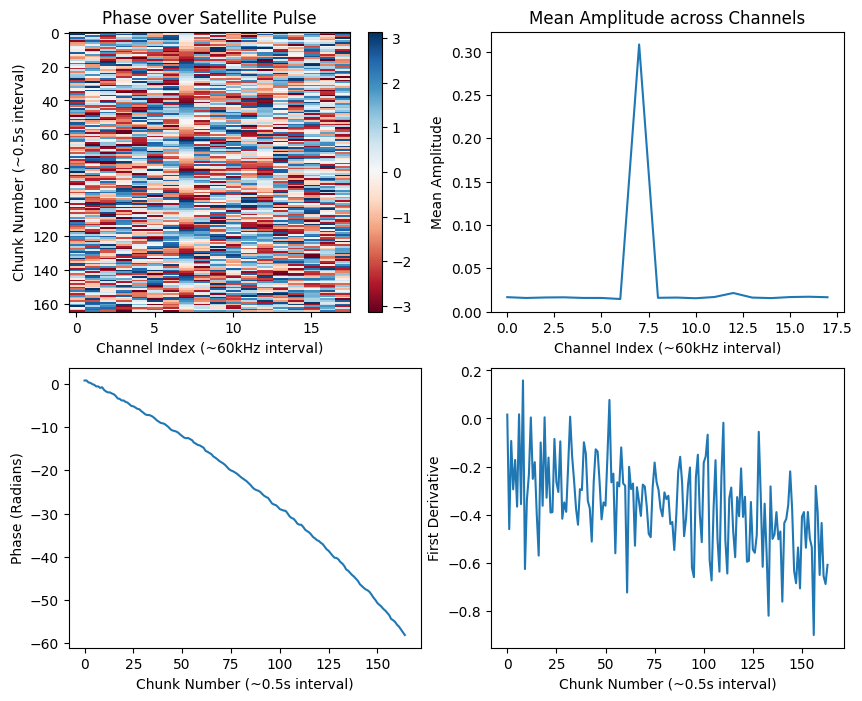

In [71]:
vis = (observed_data[0])
p_vis = np.angle(vis)
amp = np.abs(vis)

mean_amp = []
for i in range(18):
    mean_amp.append(np.mean(amp[:,i]))

chan_small_idx = np.where(mean_amp == np.max(mean_amp))[0][0]
print(chan_small_idx)

phase = np.unwrap(p_vis[:,chan_small_idx])
diff = np.diff(phase)

fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(10, 8))
ax[0,0].set_xlabel("Channel Index (~60kHz interval)")
ax[0,0].set_ylabel("Chunk Number (~0.5s interval)")
ax[0,0].set_title("Phase over Satellite Pulse")
im = ax[0,0].imshow(p_vis, aspect='auto', cmap='RdBu', interpolation="none")
fig.colorbar(im)

ax[0,1].set_xlabel("Channel Index (~60kHz interval)")
ax[0,1].set_ylabel("Mean Amplitude")
ax[0,1].set_title("Mean Amplitude across Channels")
ax[0,1].plot(mean_amp)

ax[1,0].set_xlabel("Chunk Number (~0.5s interval)")
ax[1,0].set_ylabel("Phase (Radians)")
ax[1,0].plot(phase)

ax[1,1].set_xlabel("Chunk Number (~0.5s interval)")
ax[1,1].set_ylabel("First Derivative")
ax[1,1].plot(diff)
